In [1]:
import tensorflow as tf

In [3]:
import tensorflow as tf

X = tf.random.normal([100,28,28,1])

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Reshape(input_shape=(28*28,), target_shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(kernel_size=3, filters=12, activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=6, filters=24, strides=2, activation='relu'),
    tf.keras.layers.Conv2D(kernel_size=6, filters=32, strides=2, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [8]:
x_train.shape,x_test.shape


((60000, 28, 28), (10000, 28, 28))

In [9]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [10]:
y_train[0]

np.uint8(5)

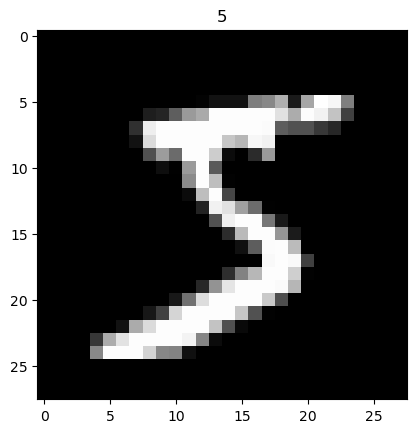

In [11]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

In [12]:
x_train = x_train.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)

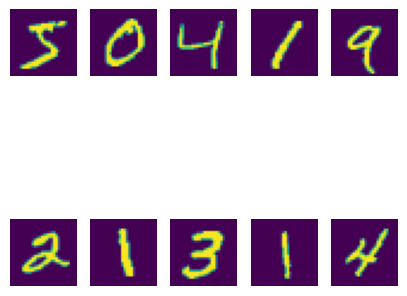

In [14]:
plt.figure(figsize=(5,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

In [15]:
x_train = x_train / 255.0
x_test  = x_test / 255.0

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 12)     │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 24)     │        10,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 32)       │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,082 (160.48 KB)

 Trainable params: 41,082 (160.48 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,Flatten,Dropout,BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,f1_score,precision_score,recall_score

In [20]:
x_train,x_val,y_train,y_val=train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [21]:
#chatgpt verdi
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
sayi_tahmin=model.fit(x_train,y_train,validation_data=(x_val,y_val),
                epochs=10, batch_size=8,callbacks=[early_stop],
                verbose=1)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9550 - loss: 0.1459 - val_accuracy: 0.9778 - val_loss: 0.0736
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9822 - val_loss: 0.0607
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9908 - loss: 0.0280 - val_accuracy: 0.9836 - val_loss: 0.0611
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9941 - loss: 0.0176 - val_accuracy: 0.9828 - val_loss: 0.0743
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9962 - loss: 0.0121 - val_accuracy: 0.9824 - val_loss: 0.0731
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.9843 - val_loss: 0.0768
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9979 - loss: 0.0063 - val_accuracy: 0.9828 - val_loss: 0.0876


In [23]:
y_pred_prob=model.predict(x_test)
y_pred=np.argmax(y_pred_prob,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
acc=accuracy_score(y_test,y_pred)
precision_macro=precision_score(y_test,y_pred,average="macro")
recall_macro=recall_score(y_test,y_pred,average="macro")
f1_macro=f1_score(y_test,y_pred,average="macro")

precision_weighted=precision_score(y_test,y_pred,average="weighted")
recall_weighted=recall_score(y_test,y_pred,average="weighted")
f1_weighted=f1_score(y_test,y_pred,average="weighted")

In [25]:
acc

0.9822

In [26]:
precision_macro

0.9823199433689712

In [27]:
recall_macro

0.982042814556325

In [28]:
f1_macro

0.9821208695724499

In [29]:
precision_weighted

0.9823076383060736

In [30]:
recall_weighted

0.9822

In [31]:
f1_weighted

0.982192802487072